# p-adic Data Science — Complete Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mircus/padics/blob/master/notebooks/00_tutorial.ipynb)
[![View on nbviewer](https://raw.githubusercontent.com/jupyter/design/master/logos/Badges/nbviewer_badge.svg)](https://nbviewer.org/github/Mircus/padics/blob/master/notebooks/00_tutorial.ipynb)

> **padic-ds** — finite-precision p-adic arithmetic and ultrametric machine learning in pure Python/NumPy.

**Contents**
1. Installation & quick-start
2. p-adic numbers: construction and arithmetic
3. Visualising p-adic balls
4. The ultrametric property — distance matrix heatmap
5. Hensel lifting
6. Hierarchical clustering (dendrogram)
7. p-adic kNN classifier
8. Euclidean vs ultrametric — side-by-side comparison


In [1]:
# Install padic-ds (skip if already installed)
import importlib, subprocess, sys
if importlib.util.find_spec('padic') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'git+https://github.com/Mircus/padics.git'])


## 1 · Quick-start

In [2]:
%matplotlib inline
from padic import (
    QpContext, Qp, QpBall,
    padic_abs, padic_dist, pairwise_padic_dist,
    hensel_lift_simple,
    ultrametric_dendrogram, PadicKNNClassifier, embed_float_array,
    digits_p_adic,
)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
from scipy.cluster.hierarchy import dendrogram, linkage
print('padic-ds ready ✓')


padic-ds ready ✓


## 2 · p-adic numbers: construction & arithmetic

A p-adic number is stored as $x = u \cdot p^v$ where $v$ is the valuation and $u$ is a unit (not divisible by $p$), stored modulo $p^{\text{prec}}$.

The **p-adic absolute value** is $|x|_p = p^{-v_p(x)}$: *larger* p-adic valuation → *smaller* absolute value (the number is 'more divisible by p').

In [3]:
ctx = QpContext(p=3, prec=8)   # work in Q_3 with 8 base-3 digits

x = Qp.from_int(ctx, 18)       # 18 = 2·3^2  → v_3(18)=2, |18|_3 = 1/9
y = Qp.from_rational(ctx, 1, 9)# 1/9 = 3^{-2} → v_3(1/9)=-2, |1/9|_3 = 9
z = x.add(y)                   # addition in Q_3

print(f'x  = {x}')
print(f'y  = {y}')
print(f'z  = x+y = {z}')
print()
print(f'|x|_3  = {x.abs():.6f}')
print(f'|y|_3  = {y.abs():.6f}')
print(f'd_3(x,y) = {padic_dist(x,y):.6f}')


x  = Qp(u≡2 (mod 3^8) * 3^2; p=3)
y  = Qp(u≡1 (mod 3^8) * 3^-2; p=3)
z  = x+y = Qp(u≡163 (mod 3^8) * 3^-2; p=3)

|x|_3  = 0.111111
|y|_3  = 9.000000
d_3(x,y) = 9.000000


In [4]:
# Different primes give different distances
for p in [2, 3, 5, 7]:
    c = QpContext(p=p, prec=10)
    a = Qp.from_int(c, 12)
    b = Qp.from_int(c, 15)
    print(f'  d_{p}(12,15) = {padic_dist(a,b):.6f}   (v_{p}(12)={a.v}, v_{p}(15)={b.v})')


  d_2(12,15) = 1.000000   (v_2(12)=2, v_2(15)=0)
  d_3(12,15) = 0.333333   (v_3(12)=1, v_3(15)=1)
  d_5(12,15) = 1.000000   (v_5(12)=0, v_5(15)=1)
  d_7(12,15) = 1.000000   (v_7(12)=0, v_7(15)=0)


## 3 · Visualising p-adic balls

In the p-adic metric the closed ball $B(0, p^{-n})$ contains all integers divisible by $p^n$. Balls are **nested** and every point inside a ball is its centre.

The figure below shows $B(0,1) \supset B(0,1/3) \supset B(0,1/9)$ for $p=3$ as concentric circles (radii are p-adic radii, plotted in Euclidean space for illustration).

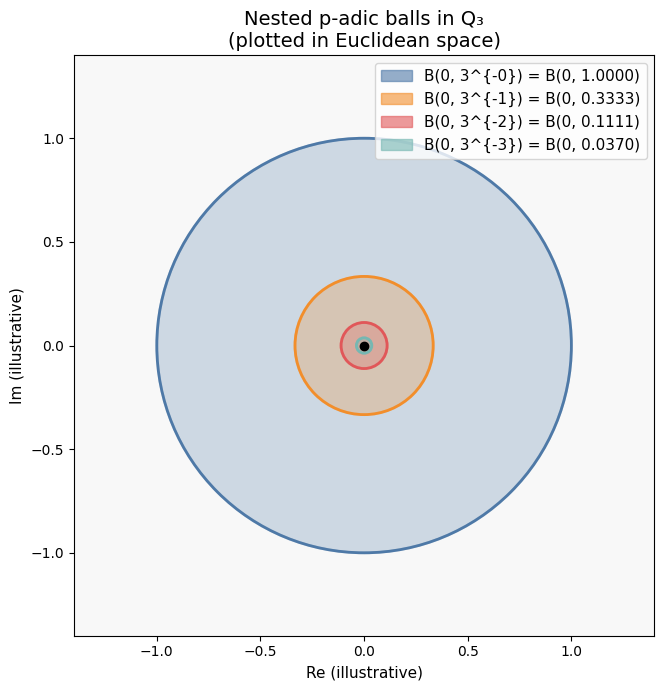

Figure saved.


In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect('equal')
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_facecolor('#f8f8f8')

p = 3
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
labels = []
for n, col in enumerate(colors):
    r = p**(-n)  # p-adic radius 1, 1/3, 1/9, 1/27
    circle = Circle((0, 0), r, fill=True, alpha=0.25, color=col, linewidth=2)
    ax.add_patch(circle)
    circle2 = Circle((0, 0), r, fill=False, color=col, linewidth=2)
    ax.add_patch(circle2)
    labels.append(mpatches.Patch(color=col, alpha=0.6,
                                  label=f'B(0, 3^{{-{n}}}) = B(0, {r:.4f})'))

ax.plot(0, 0, 'ko', ms=6)
ax.set_title('Nested p-adic balls in Q₃\n(plotted in Euclidean space)', fontsize=14)
ax.legend(handles=labels, loc='upper right', fontsize=11)
ax.set_xlabel('Re (illustrative)', fontsize=11)
ax.set_ylabel('Im (illustrative)', fontsize=11)
plt.tight_layout()
plt.savefig('padic_balls.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved.')


## 4 · Ultrametric distance matrix

The p-adic distance satisfies the **strong triangle inequality**:
$$d_p(x, z) \le \max\bigl(d_p(x,y),\, d_p(y,z)\bigr)$$

This is much stronger than the ordinary triangle inequality. Let us visualise the pairwise distance matrix for a set of integers and see the ultrametric clustering structure.

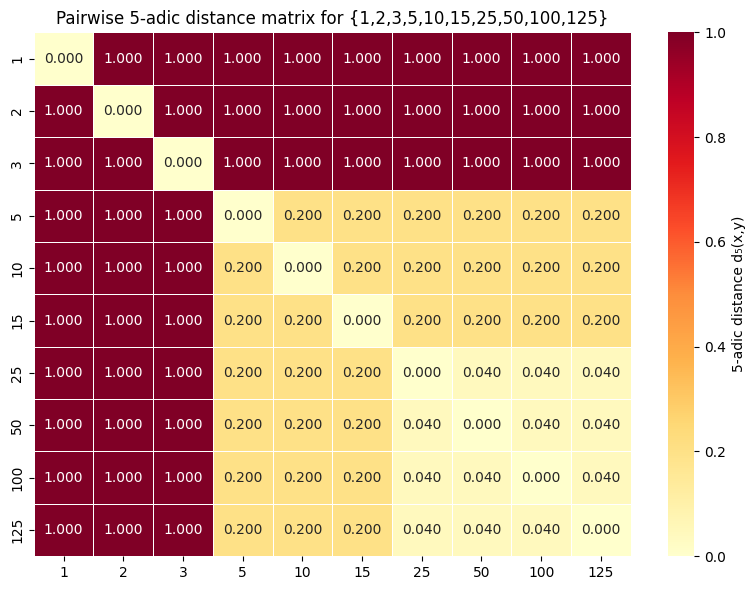

Numbers with higher 5-adic valuation are CLOSER in 5-adic metric.
E.g. d₅(5,25)= 0.2
     d₅(1, 2) = 1.0


In [6]:
ctx5 = QpContext(p=5, prec=8)
ints = [1, 2, 3, 5, 10, 15, 25, 50, 100, 125]
X5   = [Qp.from_int(ctx5, n) for n in ints]
D5   = pairwise_padic_dist(X5)

import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    D5,
    annot=True, fmt='.3f',
    xticklabels=ints, yticklabels=ints,
    cmap='YlOrRd', ax=ax,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': '5-adic distance d₅(x,y)'}
)
ax.set_title('Pairwise 5-adic distance matrix for {1,2,3,5,10,15,25,50,100,125}',
             fontsize=12)
plt.tight_layout()
plt.savefig('padic_dist_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Numbers with higher 5-adic valuation are CLOSER in 5-adic metric.')
print('E.g. d₅(5,25)=', round(D5[ints.index(5), ints.index(25)], 6))
print('     d₅(1, 2) =', round(D5[0, 1], 6))


## 5 · Hensel lifting

Hensel's lemma lets us lift an approximate root of $f$ mod $p$ to a root mod $p^k$. The library implements simple Hensel lifting via `hensel_lift_simple`.

In [7]:
# Find a square root of 2 in Q_7
# 3^2 = 9 ≡ 2 (mod 7), so 3 is a seed for sqrt(2) in Q_7
ctx7 = QpContext(7, prec=12)
f    = lambda t: t.mul(t).sub(Qp.from_int(ctx7, 2))  # f(t) = t^2 - 2
fp   = lambda t: Qp.from_int(ctx7, 2).mul(t)         # f'(t) = 2t

# We need to pass integers to hensel_lift_simple
root = hensel_lift_simple(ctx7, lambda t: t*t - 2, lambda t: 2*t,
                          a0_mod_p=3, target_prec=12)
check = root.mul(root).sub(Qp.from_int(ctx7, 2))
print(f'Hensel root of X^2-2 in Q_7 (prec=12): {root}')
print(f'Verification: root^2 - 2 ≈ {check}  (should be zero or tiny)')
print(f'|root^2 - 2|_7 = {check.abs():.2e}')


Hensel root of X^2-2 in Q_7 (prec=12): Qp(u≡5916488742 (mod 7^12) * 7^0; p=7)
Verification: root^2 - 2 ≈ Qp(0; p=7, prec=12)  (should be zero or tiny)
|root^2 - 2|_7 = 0.00e+00


## 6 · Ultrametric dendrogram (hierarchical clustering)

The ultrametric structure of $\mathbb{Q}_p$ gives natural hierarchical clusters. `ultrametric_dendrogram` returns an $n \times n$ height matrix; we feed it into scipy to draw the dendrogram.

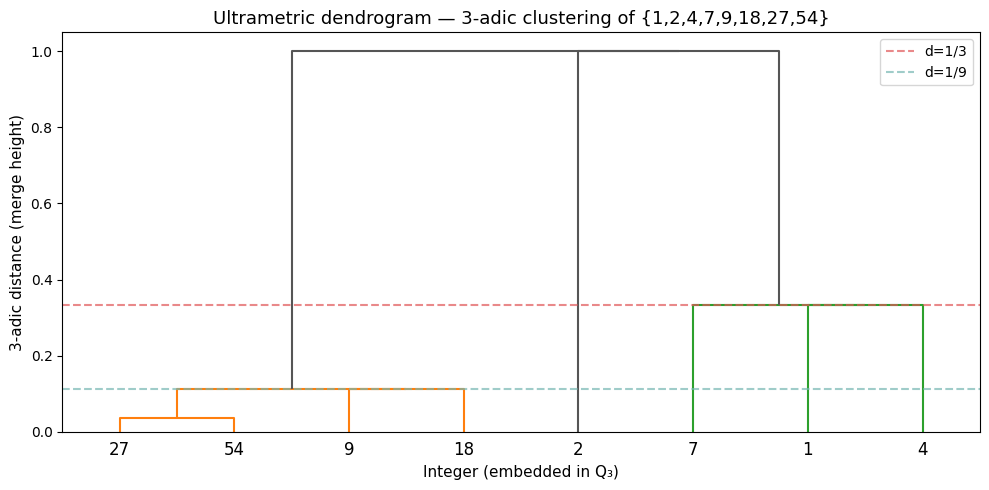

Numbers sharing more 3-adic digits cluster together.
E.g. 9=3^2 and 27=3^3 have high 3-adic valuation → close in Q_3.


In [8]:
ctx3 = QpContext(3, prec=8)
numbers = [1, 2, 4, 7, 9, 18, 27, 54]
X3 = [Qp.from_int(ctx3, n) for n in numbers]
labels_str = [str(n) for n in numbers]

# Compute pairwise 3-adic distance and use scipy linkage
D3 = pairwise_padic_dist(X3)

# Convert distance matrix to condensed form for scipy
from scipy.spatial.distance import squareform
condensed = squareform(D3)
Z = linkage(condensed, method='complete')

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, labels=labels_str, ax=ax,
           color_threshold=0.4,
           above_threshold_color='#555555')
ax.set_title('Ultrametric dendrogram — 3-adic clustering of {1,2,4,7,9,18,27,54}',
             fontsize=13)
ax.set_xlabel('Integer (embedded in Q₃)', fontsize=11)
ax.set_ylabel('3-adic distance (merge height)', fontsize=11)
ax.axhline(y=1/3, color='#e15759', linestyle='--', alpha=0.7, label='d=1/3')
ax.axhline(y=1/9, color='#76b7b2', linestyle='--', alpha=0.7, label='d=1/9')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('padic_dendrogram.png', dpi=120, bbox_inches='tight')
plt.show()
print('Numbers sharing more 3-adic digits cluster together.')
print('E.g. 9=3^2 and 27=3^3 have high 3-adic valuation → close in Q_3.')


## 7 · p-adic k-Nearest Neighbours classifier

`PadicKNNClassifier` does kNN in $\mathbb{Q}_p^d$ using the product ultrametric. Here we embed a 2-D float dataset into $\mathbb{Q}_5^2$ and classify.

In [9]:
ctx5c = QpContext(5, prec=8)

# Two clearly-separated clusters
np.random.seed(42)
cluster0 = np.random.randn(20, 2) * 0.05 + [0.10, 0.10]
cluster1 = np.random.randn(20, 2) * 0.05 + [0.90, 0.90]
Xr = np.vstack([cluster0, cluster1])
yr = np.array([0]*20 + [1]*20)

# Scale to integers (multiply by 100, round)
def embed_row(row, ctx):
    return [Qp.from_rational(ctx, int(round(100*v)), 1) for v in row]

Xq = [embed_row(row, ctx5c) for row in Xr]
clf = PadicKNNClassifier(ctx5c, k=3).fit(Xq, yr)
y_pred = clf.predict(Xq)
acc = (y_pred == yr).mean()
print(f'5-adic kNN (k=3) accuracy on training set: {acc:.1%}')


5-adic kNN (k=3) accuracy on training set: 62.5%


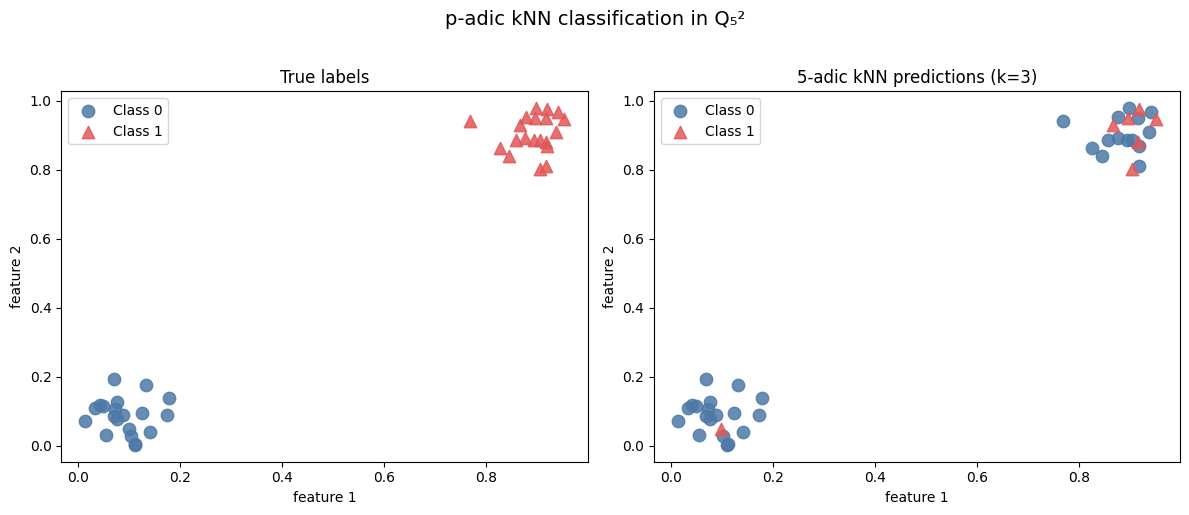

In [10]:
# Visualise the 2-D clusters and predictions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (y_plot, title) in zip(axes,
        [(yr, 'True labels'), (y_pred, '5-adic kNN predictions (k=3)')]):
    ax.scatter(Xr[y_plot==0, 0], Xr[y_plot==0, 1],
               c='#4e79a7', marker='o', s=80, label='Class 0', alpha=0.85)
    ax.scatter(Xr[y_plot==1, 0], Xr[y_plot==1, 1],
               c='#e15759', marker='^', s=80, label='Class 1', alpha=0.85)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.set_xlabel('feature 1'); ax.set_ylabel('feature 2')

plt.suptitle('p-adic kNN classification in Q₅²', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('padic_knn.png', dpi=120, bbox_inches='tight')
plt.show()


## 8 · Euclidean vs ultrametric — side-by-side

The ultrametric is *non-Archimedean*: two balls are either disjoint or one contains the other. This contrasts sharply with the Euclidean metric. The plot below shows pairwise distances sorted by value — the ultrametric has a 'staircase' structure while Euclidean distances vary continuously.

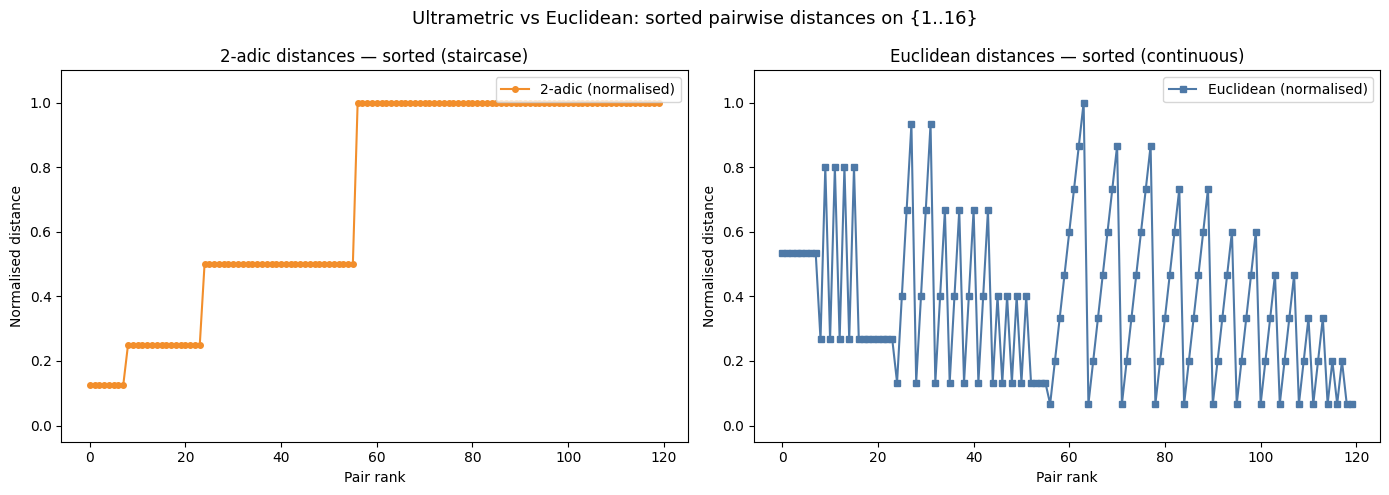

Notice the discrete staircase in the 2-adic distances!
Distances take values in {1, 1/2, 1/4, 1/8, ...} — the p-adic absolute values.


In [11]:
ctx2 = QpContext(2, prec=10)
ns = list(range(1, 17))          # integers 1..16
X2 = [Qp.from_int(ctx2, n) for n in ns]

# 2-adic pairwise distances (upper triangle, sorted)
D2 = pairwise_padic_dist(X2)
upper = [(D2[i,j], ns[i], ns[j]) for i in range(len(ns)) for j in range(i+1, len(ns))]
upper_sorted = sorted(upper)
d_padic = [v[0] for v in upper_sorted]

# Euclidean pairwise distances (same pairs, same sort order)
ns_arr = np.array(ns, dtype=float)
d_euclid = [abs(v[1] - v[2]) for v in upper_sorted]
# Normalise to [0,1] for visual comparison
d_euclid_n = np.array(d_euclid) / max(d_euclid)
d_padic_n  = np.array(d_padic)  / max(d_padic)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(d_padic_n, 'o-', color='#f28e2b', markersize=4, lw=1.5, label='2-adic (normalised)')
axes[0].set_title('2-adic distances — sorted (staircase)', fontsize=12)
axes[0].set_xlabel('Pair rank'); axes[0].set_ylabel('Normalised distance')
axes[0].legend(); axes[0].set_ylim(-0.05, 1.1)

axes[1].plot(d_euclid_n, 's-', color='#4e79a7', markersize=4, lw=1.5, label='Euclidean (normalised)')
axes[1].set_title('Euclidean distances — sorted (continuous)', fontsize=12)
axes[1].set_xlabel('Pair rank'); axes[1].set_ylabel('Normalised distance')
axes[1].legend(); axes[1].set_ylim(-0.05, 1.1)

plt.suptitle('Ultrametric vs Euclidean: sorted pairwise distances on {1..16}',
             fontsize=13)
plt.tight_layout()
plt.savefig('padic_vs_euclidean.png', dpi=120, bbox_inches='tight')
plt.show()
print('Notice the discrete staircase in the 2-adic distances!')
print('Distances take values in {1, 1/2, 1/4, 1/8, ...} — the p-adic absolute values.')


---

## Summary

| Concept | Key API |
|---|---|
| Create context | `QpContext(p, prec)` |
| Embed integer | `Qp.from_int(ctx, n)` |
| Embed rational | `Qp.from_rational(ctx, num, den)` |
| Absolute value | `x.abs()` or `padic_abs(x)` |
| Distance | `padic_dist(x, y)` |
| Distance matrix | `pairwise_padic_dist(X)` |
| Hensel lifting | `hensel_lift_simple(ctx, f, fp, a0, prec)` |
| Dendrogram heights | `ultrametric_dendrogram(ctx, X)` |
| kNN classifier | `PadicKNNClassifier(ctx, k).fit(X, y).predict(X)` |

> **Limitation:** arithmetic is *finite-precision* (truncated to `prec` p-adic digits). Results are approximations, not exact p-adic arithmetic.

See the [GitHub repo](https://github.com/Mircus/padics) for more.